In [ ]:
# libraries
import os
import sys
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score, fbeta_score
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# directories
working_dir = "/Users/natsudanav/Desktop/PRIMEloci/evaluation"
os.chdir(working_dir)


# directories
working_dir = "/home/zmk214/zmk214/PRIMEloci/evaluation/model_evaluation"

data_dir = "/Users/natsudanav/Desktop/PRIMEloci/evaluation/model_evaluation/data/GM12878_wt10M_profiles_te/predictions"
result_dir = "/Users/natsudanav/Desktop/PRIMEloci/evaluation/model_evaluation/results/"

os.chdir(working_dir)

In [ ]:
# Create output directory if it doesn't exist
output_dir = "output_reports"
os.makedirs(output_dir, exist_ok=True)

# Function to save plots
def save_plot(fig, name):
    fig.savefig(os.path.join(output_dir, f"{name}.pdf"), format="pdf", bbox_inches="tight", dpi=300)

# Function to save reports
def save_report(content, name):
    with open(os.path.join(output_dir, f"{name}.txt"), "w") as f:
        f.write(content)


In [25]:
# Define a function to parse information from filenames
def parse_filename(filename):
    parts = filename.split('_')
    
    class_label = parts[5]  # e.g., "neg" or "pos"
    dataset = parts[6]      # e.g., "te" or "tr"
    augmentation = "aug" if "aug" in parts else "no_aug"
    cage = parts[-3]  # e.g., "N"
    cell = parts[-2]  # e.g., "1mio"

    # Define augmentation conditions
    if class_label == "neg" and augmentation == "aug":
        augmentation = "aug_neg"
    elif class_label == "neg" and augmentation == "no_aug":
        augmentation = "npn"
    elif class_label == "pos" and augmentation == "no_aug":
        augmentation = "orig_pos"
    elif class_label == "pos" and augmentation == "aug":
        augmentation = "aug_pos"
    
    return class_label, dataset, augmentation, cage, cell

In [26]:
# Get all .bed files in the current directory
bed_files = [f for f in os.listdir(data_dir) if f.endswith('.bed')]

In [27]:
# Initialize an empty DataFrame to combine all data
combined_df = pd.DataFrame()

In [28]:
# Process each file
for bed_file in bed_files:
    # Parse the information from the filename (remove the .bed extension)
    filename = os.path.splitext(bed_file)[0]
    class_label, dataset, augmentation, cage, cell = parse_filename(filename)
    
    # Read the BED file
    bed_file_path = os.path.join(data_dir, bed_file)
    if os.path.exists(bed_file_path):
        bed_df = pd.read_csv(bed_file_path, sep='\t', header=0)

        # Add new columns based on filename information
        bed_df['Class'] = class_label
        bed_df['Dataset'] = dataset
        bed_df['Augmentation'] = augmentation
        bed_df['CAGE'] = cage
        bed_df['Cell'] = cell

        # Append to the combined DataFrame
        combined_df = pd.concat([combined_df, bed_df], ignore_index=True)
    else:
        print(f"File not found: {bed_file_path}")

In [29]:
combined_df

,chrom,chromStart,chromEnd,name,score,strand,sum_count,annotation,Class,Dataset,Augmentation,CAGE,Cell
0,chr2,227614.0,228015,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_1...,0.457315,*,6,intron,neg,te,aug_neg,C,1mio
1,chr2,232403.0,232804,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_1...,0.376479,*,4,intron,neg,te,aug_neg,C,1mio
2,chr2,265332.0,265733,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_1...,0.389652,*,5,proximal,neg,te,aug_neg,C,1mio
3,chr2,273006.0,273407,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_1...,0.498871,*,7,threeUTR,neg,te,aug_neg,C,1mio
4,chr2,275166.0,275567,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_1...,0.453224,*,17,threeUTR,neg,te,aug_neg,C,1mio
...,...,...,...,...,...,...,...,...,...,...,...,...,...
600409,chr4,189930743.0,189931144,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_5...,0.412906,*,8,intron,neg,te,aug_neg,C,500k
600410,chr4,189939586.0,189939987,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_5...,0.622874,*,67,promoter,neg,te,aug_neg,C,500k
600411,chr4,189939607.0,189940008,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_5...,0.559173,*,67,promoter,neg,te,aug_neg,C,500k
600412,chr4,189940139.0,189940540,profiles_subtnorm_neg_te_aug_GM12878_reseq_C_5...,0.439518,*,9,promoter,neg,te,aug_neg,C,500k


In [30]:
output_file = os.path.join(result_dir, "all_te_prediction.bed")
combined_df.to_csv(output_file, sep='\t', index=False, header=False)
print(f"Combined data saved: {output_file}")

Combined data saved: /Users/natsudanav/Desktop/PRIMEloci/evaluation/model_evaluation/results/all_te_prediction.bed


In [31]:
# Extract true labels and predicted probabilities
true_labels = combined_df['Class'].apply(lambda x: 1 if x == 'pos' else 0)  # Convert 'pos' to 1, 'neg' to 0
predicted_probs = combined_df['score']

# Set a threshold to create binary predictions
threshold = 0.50
predicted_labels = (predicted_probs >= threshold).astype(int)

In [32]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[203977  96206]
 [158134 142097]]


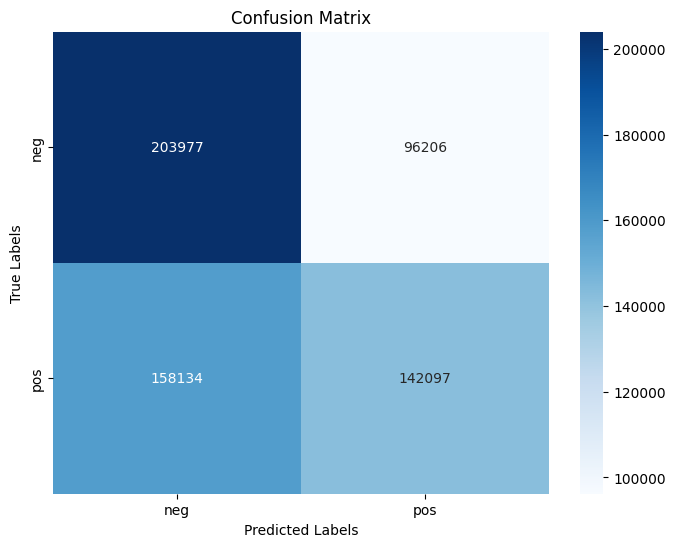

In [33]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [34]:
# Classification Report
report = classification_report(true_labels, predicted_labels, target_names=['neg', 'pos'])
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

         neg       0.56      0.68      0.62    300183
         pos       0.60      0.47      0.53    300231

    accuracy                           0.58    600414
   macro avg       0.58      0.58      0.57    600414
weighted avg       0.58      0.58      0.57    600414



In [59]:
# Function to generate classification report for each group
def generate_classification_report(input_df, group_by_columns, threshold=0.5):
    group_reports = {}
    
    # Group data by specified columns
    grouped = input_df.groupby(group_by_columns)
    
    for group, group_df in grouped:
        true_labels = group_df['Class'].apply(lambda x: 1 if x == 'pos' else 0)
        predicted_probs = group_df['score']
        predicted_labels = (predicted_probs >= threshold).astype(int)
        
        # Generate classification report for this group
        report = classification_report(
            true_labels,
            predicted_labels,
            target_names=['neg', 'pos'],
            output_dict=True,  # Use dict for better handling
            zero_division=0
        )
        
        # Save report as dictionary with the group as key
        group_reports[group] = report
        
        # Print the report for each group
        print(f"\nClassification Report for group {group}:")
        print("threshold = ", threshold)
        print(classification_report(
            true_labels,
            predicted_labels,
            target_names=['neg', 'pos'],
            zero_division=0
        ))
    
    return group_reports

In [61]:
# Classification report by 'CAGE'
print("\nClassification Report by CAGE")
cage_reports = generate_classification_report(combined_df, ['CAGE'], threshold=threshold)


Classification Report by CAGE

Classification Report for group ('C',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.58      0.73      0.65     78337
         pos       0.63      0.47      0.54     78357

    accuracy                           0.60    156694
   macro avg       0.61      0.60      0.59    156694
weighted avg       0.61      0.60      0.59    156694


Classification Report for group ('N',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.56      0.66      0.61    221846
         pos       0.58      0.47      0.52    221874

    accuracy                           0.57    443720
   macro avg       0.57      0.57      0.56    443720
weighted avg       0.57      0.57      0.56    443720



In [62]:
# Classification report by 'CAGE+Cell'
print("\nClassification Report by CAGE+Cell")
combined_df['CAGE+Cell'] = combined_df['CAGE'] + '+' + combined_df['Cell']  # Combine columns
cage_cell_reports = generate_classification_report(combined_df, ['CAGE+Cell'], threshold=threshold)



Classification Report by CAGE+Cell

Classification Report for group ('C+1mio',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.58      0.70      0.64     36750
         pos       0.62      0.49      0.55     36760

    accuracy                           0.60     73510
   macro avg       0.60      0.60      0.59     73510
weighted avg       0.60      0.60      0.59     73510


Classification Report for group ('C+500k',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.58      0.75      0.65     41587
         pos       0.65      0.46      0.54     41597

    accuracy                           0.60     83184
   macro avg       0.61      0.60      0.59     83184
weighted avg       0.61      0.60      0.59     83184


Classification Report for group ('N+10mio',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.56      0.63      0.59    123888
         po

In [63]:
# Classification report by 'annotation'
print("\nClassification Report by CAGE")
cage_reports = generate_classification_report(combined_df, ['annotation'], threshold=threshold)


Classification Report by CAGE

Classification Report for group ('CDS',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       1.00      0.68      0.81     10873
         pos       0.00      0.00      0.00         0

    accuracy                           0.68     10873
   macro avg       0.50      0.34      0.41     10873
weighted avg       1.00      0.68      0.81     10873


Classification Report for group ('exon',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       1.00      0.70      0.83      7602
         pos       0.00      0.00      0.00         0

    accuracy                           0.70      7602
   macro avg       0.50      0.35      0.41      7602
weighted avg       1.00      0.70      0.83      7602


Classification Report for group ('fiveUTR',):
threshold =  0.5
              precision    recall  f1-score   support

         neg       0.45      0.65      0.53      3086
         pos       0.

In [ ]:
# ROC Curve and AUC
fpr, tpr, roc_thresholds = roc_curve(true_labels, predicted_probs)
roc_auc = auc(fpr, tpr)
print(f"\nROC AUC: {roc_auc:.4f}")


ROC AUC: 0.6048


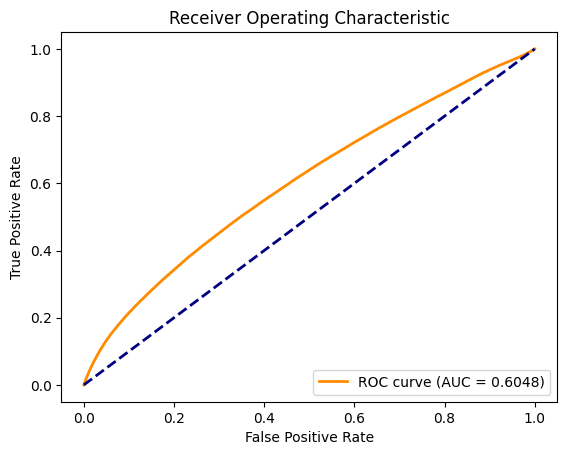

In [ ]:
# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()

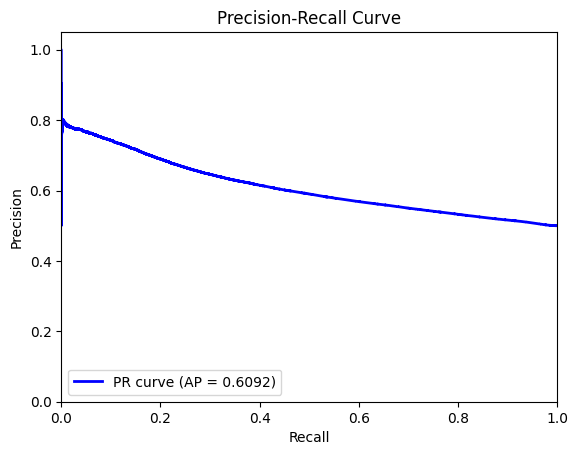

In [ ]:
precision, recall, pr_thresholds = precision_recall_curve(true_labels, predicted_probs)
avg_precision = average_precision_score(true_labels, predicted_probs)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label=f"PR curve (AP = {avg_precision:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

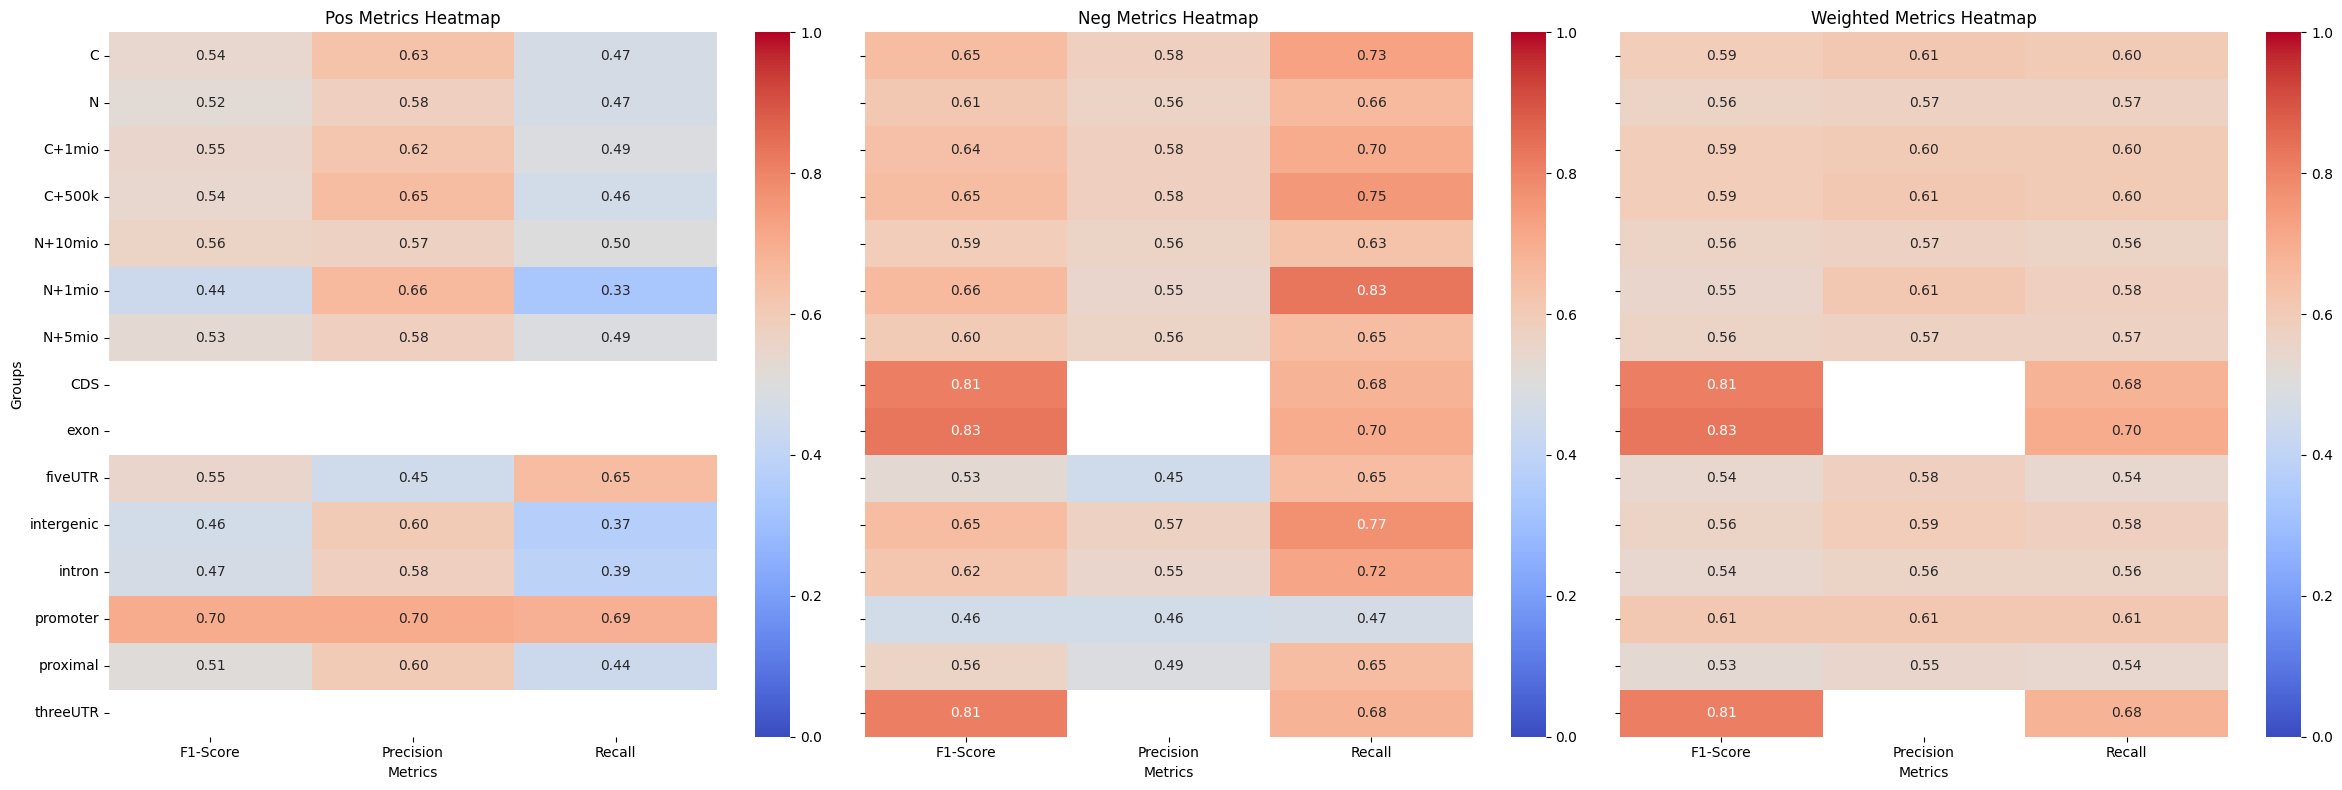

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Data for positive metrics
data_pos = {
    'Group': ['C', 'N', 'C+1mio', 'C+500k', 'N+10mio', 'N+1mio', 'N+5mio', 'CDS', 'exon', 'fiveUTR', 'intergenic', 'intron', 'promoter', 'proximal', 'threeUTR'],
    'F1-Score': [0.54, 0.52, 0.55, 0.54, 0.56, 0.44, 0.53, 0.00, 0.00, 0.55, 0.46, 0.47, 0.70, 0.51, 0.00],
    'Precision': [0.63, 0.58, 0.62, 0.65, 0.57, 0.66, 0.58, 0.00, 0.00, 0.45, 0.60, 0.58, 0.70, 0.60, 0.00],
    'Recall': [0.47, 0.47, 0.49, 0.46, 0.50, 0.33, 0.49, 0.00, 0.00, 0.65, 0.37, 0.39, 0.69, 0.44, 0.00],
}

# Data for negative metrics
data_neg = {
    'Group': ['C', 'N', 'C+1mio', 'C+500k', 'N+10mio', 'N+1mio', 'N+5mio', 'CDS', 'exon', 'fiveUTR', 'intergenic', 'intron', 'promoter', 'proximal', 'threeUTR'],
    'F1-Score': [0.65, 0.61, 0.64, 0.65, 0.59, 0.66, 0.60, 0.81, 0.83, 0.53, 0.65, 0.62, 0.46, 0.56, 0.81],
    'Precision': [0.58, 0.56, 0.58, 0.58, 0.56, 0.55, 0.56, 1.00, 1.00, 0.45, 0.57, 0.55, 0.46, 0.49, 1.00],
    'Recall': [0.73, 0.66, 0.70, 0.75, 0.63, 0.83, 0.65, 0.68, 0.70, 0.65, 0.77, 0.72, 0.47, 0.65, 0.68],
}

# Data for weighted metrics
data_weighted = {
    'Group': ['C', 'N', 'C+1mio', 'C+500k', 'N+10mio', 'N+1mio', 'N+5mio', 'CDS', 'exon', 'fiveUTR', 'intergenic', 'intron', 'promoter', 'proximal', 'threeUTR'],
    'F1-Score': [0.59, 0.56, 0.59, 0.59, 0.56, 0.55, 0.56, 0.81, 0.83, 0.54, 0.56, 0.54, 0.61, 0.53, 0.81],
    'Precision': [0.61, 0.57, 0.60, 0.61, 0.57, 0.61, 0.57, 1.00, 1.00, 0.58, 0.59, 0.56, 0.61, 0.55, 1.00],
    'Recall': [0.60, 0.57, 0.60, 0.60, 0.56, 0.58, 0.57, 0.68, 0.70, 0.54, 0.58, 0.56, 0.61, 0.54, 0.68],
}

# Convert to DataFrames
df_pos = pd.DataFrame(data_pos).set_index('Group')
df_neg = pd.DataFrame(data_neg).set_index('Group')
df_weighted = pd.DataFrame(data_weighted).set_index('Group')

# Create masks for values to be greyed out (1.00 and 0.00)
mask_pos = (df_pos == 1.00) | (df_pos == 0.00)
mask_neg = (df_neg == 1.00) | (df_neg == 0.00)
mask_weighted = (df_weighted == 1.00) | (df_weighted == 0.00)

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# Positive metrics
sns.heatmap(df_pos, annot=True, mask=mask_pos, cmap='coolwarm', fmt='.2f', cbar=True, vmin=0, vmax=1, ax=axes[0])
sns.heatmap(df_pos.where(mask_pos), mask=~mask_pos, cmap='Greys', annot=False, cbar=False, ax=axes[0])
axes[0].set_title("Pos Metrics Heatmap")
axes[0].set_xlabel("Metrics")
axes[0].set_ylabel("Groups")

# Negative metrics
sns.heatmap(df_neg, annot=True, mask=mask_neg, cmap='coolwarm', fmt='.2f', cbar=True, vmin=0, vmax=1, ax=axes[1])
sns.heatmap(df_neg.where(mask_neg), mask=~mask_neg, cmap='Greys', annot=False, cbar=False, ax=axes[1])
axes[1].set_title("Neg Metrics Heatmap")
axes[1].set_xlabel("Metrics")
axes[1].set_ylabel("")

# Weighted metrics
sns.heatmap(df_weighted, annot=True, mask=mask_weighted, cmap='coolwarm', fmt='.2f', cbar=True, vmin=0, vmax=1, ax=axes[2])
sns.heatmap(df_weighted.where(mask_weighted), mask=~mask_weighted, cmap='Greys', annot=False, cbar=False, ax=axes[2])
axes[2].set_title("Weighted Metrics Heatmap")
axes[2].set_xlabel("Metrics")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()
